In [52]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,root_mean_squared_error,r2_score

In [53]:
df = pd.read_csv('cancer-probabilities.csv')

In [54]:
df.head()

,Sr No.,Smoking Habit,Drinking Habit,Biking Habit,Walking Habit,Jogging Habit,Probability of Cancer
0,1,Heavy,Frequent,Low,Low,Low,0.8
1,2,Occasional,Moderate,High,High,High,0.2
2,3,NaN,NaN,High,High,High,0.1
3,4,Heavy,Frequent,Low,Low,Low,0.9
4,5,Moderate,Occasional,Medium,Medium,Medium,0.4


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sr No.                 50 non-null     int64  
 1   Smoking Habit          34 non-null     object 
 2   Drinking Habit         34 non-null     object 
 3   Biking Habit           50 non-null     object 
 4   Walking Habit          50 non-null     object 
 5   Jogging Habit          50 non-null     object 
 6   Probability of Cancer  50 non-null     float64
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ KB


In [56]:
df.describe()

,Sr No.,Probability of Cancer
count,50.00000,50.000000
mean,25.50000,0.407200
std,14.57738,0.325501
min,1.00000,0.010000
25%,13.25000,0.050000
50%,25.50000,0.375000
75%,37.75000,0.750000
max,50.00000,0.900000


In [57]:
df = df.drop(columns=['Sr No.'])

In [58]:
df.head()

,Smoking Habit,Drinking Habit,Biking Habit,Walking Habit,Jogging Habit,Probability of Cancer
0,Heavy,Frequent,Low,Low,Low,0.8
1,Occasional,Moderate,High,High,High,0.2
2,NaN,NaN,High,High,High,0.1
3,Heavy,Frequent,Low,Low,Low,0.9
4,Moderate,Occasional,Medium,Medium,Medium,0.4


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

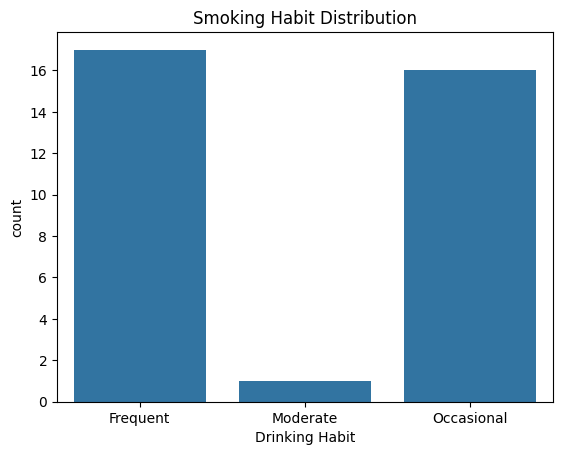

In [60]:
sns.countplot(x='Drinking Habit',data=df)
plt.title("Smoking Habit Distribution")
plt.show()

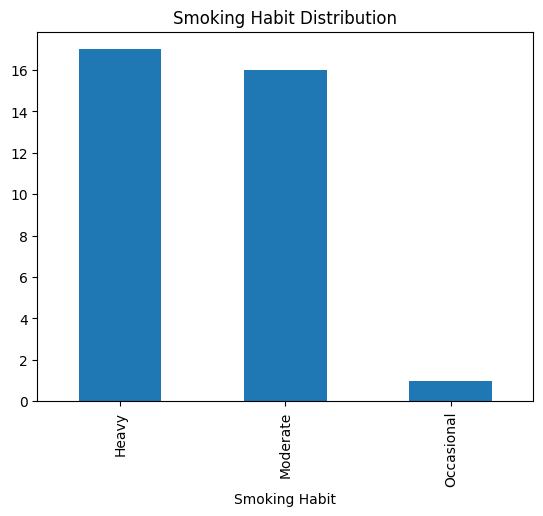

In [61]:
df['Smoking Habit'].value_counts().plot(kind='bar')
plt.title("Smoking Habit Distribution")
plt.show()

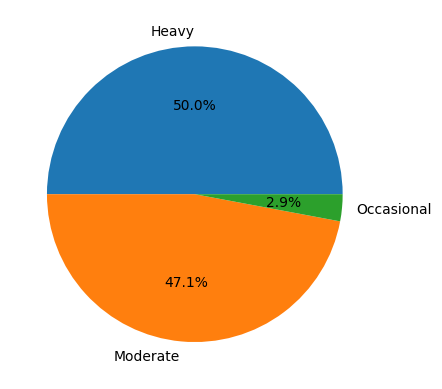

In [62]:
df["Smoking Habit"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.show()

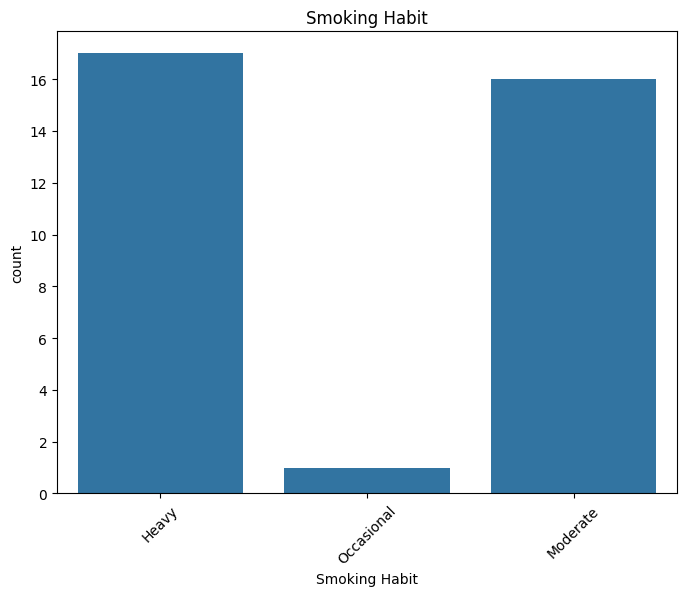

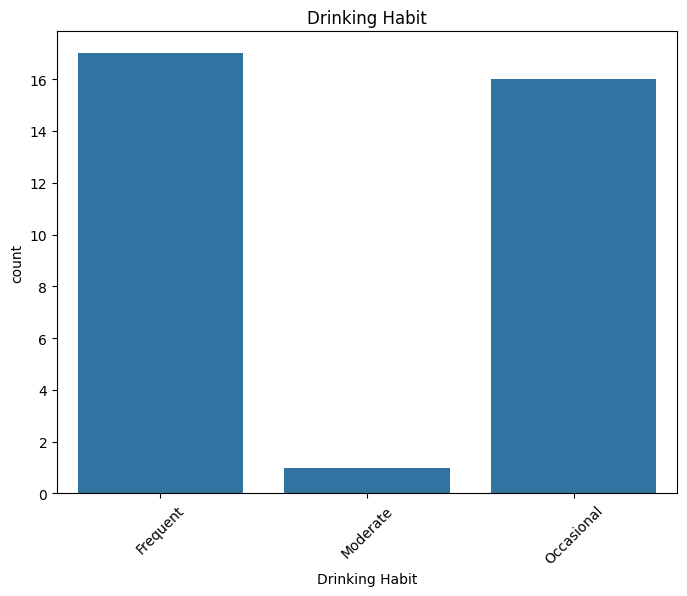

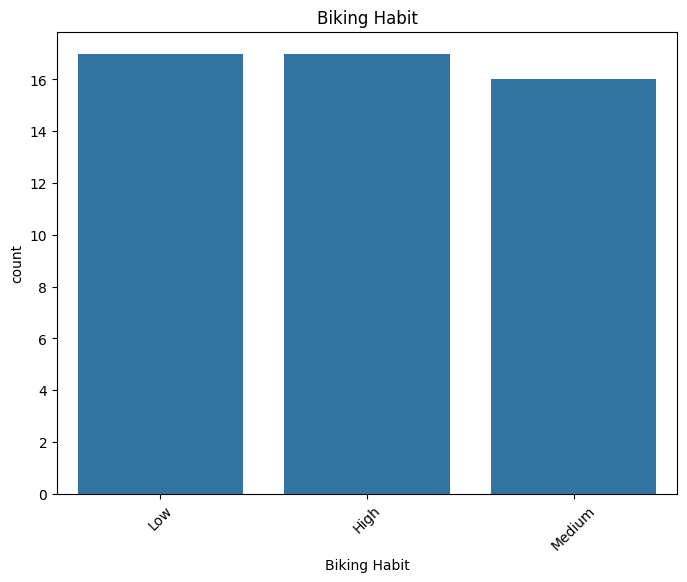

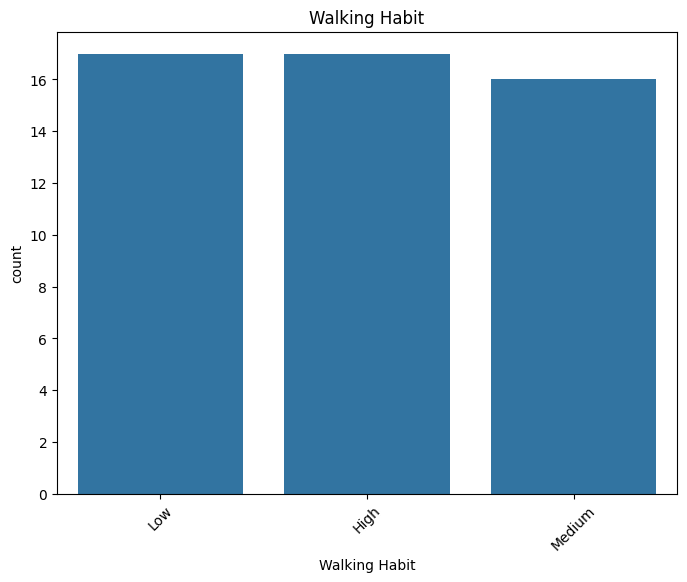

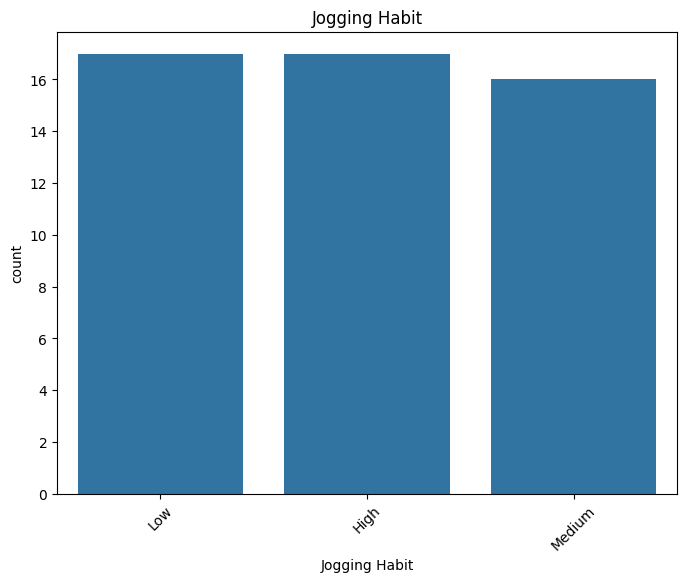

In [63]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
  plt.figure(figsize=(8,6))
  sns.countplot(x=col,data=df)
  plt.title(col)
  plt.xticks(rotation=45)
  plt.show()

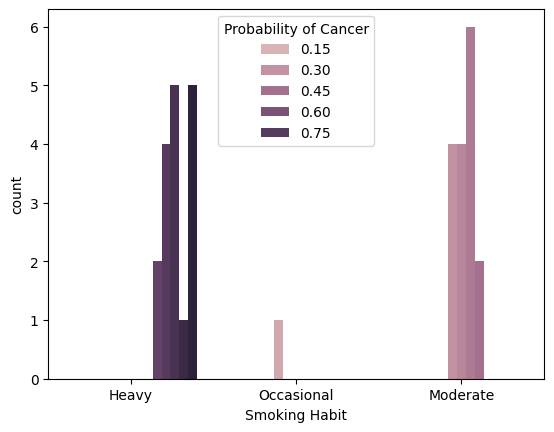

In [64]:
sns.countplot(
    x="Smoking Habit",
    hue="Probability of Cancer",
    data=df
)

plt.show()

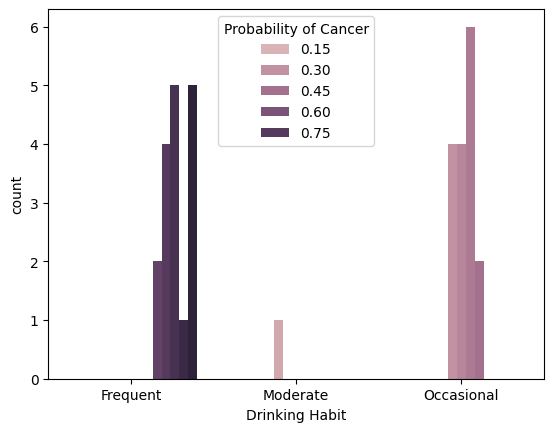

In [65]:
sns.countplot(
    x="Drinking Habit",
    hue="Probability of Cancer",
    data=df
)

plt.show()

In [66]:
print(df["Smoking Habit"].value_counts())

Smoking Habit
Heavy         17
Moderate      16
Occasional     1
Name: count, dtype: int64


In [67]:
print(df["Smoking Habit"].value_counts(normalize=True)*100)

Smoking Habit
Heavy         50.000000
Moderate      47.058824
Occasional     2.941176
Name: proportion, dtype: float64


In [68]:
df.head()

,Smoking Habit,Drinking Habit,Biking Habit,Walking Habit,Jogging Habit,Probability of Cancer
0,Heavy,Frequent,Low,Low,Low,0.8
1,Occasional,Moderate,High,High,High,0.2
2,NaN,NaN,High,High,High,0.1
3,Heavy,Frequent,Low,Low,Low,0.9
4,Moderate,Occasional,Medium,Medium,Medium,0.4


In [69]:
X = df.drop(columns=['Probability of Cancer'])
y = df['Probability of Cancer']

In [77]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [87]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor

In [90]:
encoder = OrdinalEncoder()
X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)
pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('model',RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])
pipeline.fit(X_train,y_train)
y_pred1 = pipeline.predict(X_test)

In [92]:
d = DecisionTreeRegressor(random_state=42,max_depth=5)
d.fit(X_train,y_train)
y_pred2 = d.predict(X_test)

In [93]:
print(r2_score(y_test,y_pred1))
print(r2_score(y_test,y_pred2))

0.9750378467785736
0.9740502211131578


In [94]:
print(mean_squared_error(y_test,y_pred1))
print(mean_squared_error(y_test,y_pred2))

0.0029481551062165664
0.0030647986354305017


In [95]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder()),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)